# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [2]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Modules
Python_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode
Data_folder: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [3]:
import itertools
import os
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from Modules.Load_RF_forecast_models import load_rf_models
from Modules.Validation2 import _build_validation_folds, smape
import Modules.week_predictions as wp

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Exogenous feature RF models used by the production feature-forecasting pipeline.
rf_models = load_rf_models(user="Nikolaj")

# Cache exogenous forecasts across parameter combinations.
_ARIMAX_EXOG_CACHE = {}


def _prepare_target_series(data, target_col):
    series = (
        data[["Time", target_col]]
        .copy()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .set_index("Time")[target_col]
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    return series.asfreq("h")


def _get_feature_columns(dataset, target_col):
    feature_columns = []
    for col in [c for c in dataset.columns if c not in {"Time", target_col}]:
        base_feature, lag_hours = wp._parse_lag_feature(col)
        if lag_hours is not None:
            resolved_base = wp._resolve_base_feature(base_feature, target_col)
            if resolved_base == target_col:
                continue
        feature_columns.append(col)
    return feature_columns


def _clean_exog(exog_df):
    exog = exog_df.copy()
    exog = exog.replace([np.inf, -np.inf], np.nan)
    exog = exog.ffill().bfill().fillna(0.0)
    return exog.astype(float)


def _forecast_exog_for_period(dataset, period_start, period_end, feature_columns, dk_zone, rf_models, forecast_horizon=168):
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    target_col = data.columns[0]
    cache_key = (
        str(data["Time"].min()),
        str(data["Time"].max()),
        len(data),
        str(period_start),
        str(period_end),
        tuple(feature_columns),
        dk_zone,
        int(forecast_horizon),
        bool(rf_models),
    )

    if cache_key in _ARIMAX_EXOG_CACHE:
        print("  Using cached exogenous forecast...", flush=True)
        return _ARIMAX_EXOG_CACHE[cache_key].copy()

    horizon_mask = (data["Time"] >= period_start) & (data["Time"] <= period_end)
    horizon_hours = data.loc[horizon_mask, "Time"].tolist()
    if not horizon_hours:
        raise ValueError("No timestamps found in selected period.")

    simulated_history = data.loc[data["Time"] < period_start].copy().reset_index(drop=True)
    if simulated_history.empty:
        raise ValueError("Need historical rows before period_start to construct lags.")

    present_forecast_features = [
        feat for feat in wp.FORECASTABLE_FEATURES if feat in data.columns and feat != target_col
    ]
    non_rf_features = [
        feat
        for feat in present_forecast_features
        if wp.FORECAST_METHODS[dk_zone].get(feat) in {"lag24", "lag168", "last_known_value", "skforecast"}
    ]
    rf_features = [
        feat for feat in present_forecast_features if wp.FORECAST_METHODS[dk_zone].get(feat) == "rf"
    ]

    block_frames = []
    block_start_idx = 0

    while block_start_idx < len(horizon_hours):
        block_hours = horizon_hours[block_start_idx:block_start_idx + forecast_horizon]
        block_true = data.loc[data["Time"].isin(block_hours)].copy().reset_index(drop=True)
        block_df = pd.DataFrame({"Time": block_true["Time"]})

        for col in wp.KNOWN_FUTURE_FEATURES + wp.WEATHER_FEATURES + wp.CAPACITY_FEATURES:
            if col in block_true.columns:
                block_df[col] = block_true[col].to_numpy()

        print("  Forecasting non-RF features...", flush=True)
        for feature_name in non_rf_features:
            method = wp.FORECAST_METHODS[dk_zone][feature_name]
            if method == "lag24":
                block_df[feature_name] = wp._forecast_lag_feature_for_week(
                    simulated_history, block_df, feature_name, 24
                )
            elif method == "lag168":
                block_df[feature_name] = wp._forecast_lag_feature_for_week(
                    simulated_history, block_df, feature_name, 168
                )
            elif method == "last_known_value":
                block_df[feature_name] = wp._forecast_last_known_value_for_week(
                    simulated_history, feature_name, len(block_df)
                )
            elif method == "skforecast":
                block_df[feature_name] = wp._forecast_skforecast_feature_for_week(
                    simulated_history, block_df, feature_name, offset=168, n_offsets=3, agg_func=np.mean
                )
            else:
                raise ValueError(f"Unsupported forecast method '{method}' for {feature_name}.")

        print("  Forecasting RF features...", flush=True)
        feature_no = 0
        for feature_name in rf_features:
            feature_no += 1
            print(f"  - Forecasting {feature_no}/{len(rf_features)}: {feature_name} ", flush=True)
            if rf_models is None or not rf_models:
                raise ValueError("rf_models are required to forecast RF-based exogenous features.")
            block_df[feature_name] = wp._forecast_rf_feature_for_week(
                simulated_history, block_df, feature_name, dk_zone, rf_models
            )

        for col in feature_columns:
            if col in block_df.columns:
                continue
            if col in block_true.columns:
                block_df[col] = block_true[col].to_numpy()
                continue

            base_feature, lag_hours = wp._parse_lag_feature(col)
            if lag_hours is None:
                block_df[col] = np.nan
                continue

            resolved_base = wp._resolve_base_feature(base_feature, target_col)
            if resolved_base == target_col:
                block_df[col] = np.nan
                continue
            
            print("  Computing lag features...")
            lag_vals = [
                wp._value_from_lag(simulated_history, block_df, resolved_base, ts, lag_hours)
                for ts in block_df["Time"]
            ]
            block_df[col] = lag_vals

        block_exog = block_df[["Time"] + feature_columns].copy()
        block_frames.append(block_exog)

        history_append = block_df.copy()
        for col in data.columns:
            if col not in history_append.columns:
                history_append[col] = np.nan
        history_append = history_append[data.columns]
        simulated_history = pd.concat([simulated_history, history_append], ignore_index=True)

        block_start_idx += forecast_horizon

    exog_forecast = pd.concat(block_frames, ignore_index=True)
    exog_forecast = exog_forecast.drop_duplicates(subset="Time").sort_values("Time")
    exog_forecast = exog_forecast.set_index("Time")[feature_columns]
    cleaned_exog_forecast = _clean_exog(exog_forecast)
    _ARIMAX_EXOG_CACHE[cache_key] = cleaned_exog_forecast.copy()
    return cleaned_exog_forecast


def _fit_arimax(train_series, train_exog, order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        fitted_model = ARIMA(
            train_series,
            exog=_clean_exog(train_exog),
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    return fitted_model


def _build_weekly_and_daily_metrics(actual, predicted, fold_no, week_no):
    evaluation = pd.DataFrame(
        {
            "Time": actual.index,
            "Actual": actual.values,
            "Prediction": predicted.reindex(actual.index).values,
        }
    )
    evaluation["Date"] = evaluation["Time"].dt.floor("D")

    rmse = float(np.sqrt(np.mean((evaluation["Actual"] - evaluation["Prediction"]) ** 2)))
    mae = float(np.mean(np.abs(evaluation["Actual"] - evaluation["Prediction"])))
    smape_value = float(smape(evaluation["Actual"].values, evaluation["Prediction"].values))

    weekly_row = {
        "fold": fold_no,
        "week": week_no,
        "week_start": evaluation["Time"].min(),
        "week_end": evaluation["Time"].max(),
        "weekly_rmse": rmse,
        "weekly_mae": mae,
        "weekly_smape": smape_value,
    }

    daily_rows = []
    for date, day_group in evaluation.groupby("Date"):
        daily_rows.append(
            {
                "Date": date,
                "daily_rmse": float(
                    np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))
                ),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                "fold": fold_no,
                "week": week_no,
            }
        )

    return weekly_row, pd.DataFrame(daily_rows)

c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: Currently logged in as: nande24 (Energinet_speciale) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'rf_OffshoreWindPower_DK1:latest', 1817.80MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3323.2MB/s)


✓ Loaded RF model for OffshoreWindPower_DK1 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\OffshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK2:latest', 1809.79MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (6093.6MB/s)


✓ Loaded RF model for OffshoreWindPower_DK2 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\OffshoreWindPower_DK2


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK1:latest', 1817.91MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (6141.6MB/s)


✓ Loaded RF model for OnshoreWindPower_DK1 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\OnshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK2:latest', 1815.11MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5533.9MB/s)


✓ Loaded RF model for OnshoreWindPower_DK2 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\OnshoreWindPower_DK2


wandb: Downloading large artifact 'rf_SolarPower_DK1:latest', 1666.36MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5610.6MB/s)


✓ Loaded RF model for SolarPower_DK1 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\SolarPower_DK1


wandb: Downloading large artifact 'rf_SolarPower_DK2:latest', 1580.46MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5964.0MB/s)


✓ Loaded RF model for SolarPower_DK2 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\SolarPower_DK2


wandb: Downloading large artifact 'rf_TotalProduction_DK1:latest', 1817.61MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (6140.6MB/s)


✓ Loaded RF model for TotalProduction_DK1 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\TotalProduction_DK1


wandb: Downloading large artifact 'rf_TotalProduction_DK2:latest', 1817.23MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (6857.5MB/s)


✓ Loaded RF model for TotalProduction_DK2 from C:\Users\n_and\Documents\Data Science\Speciale\Shallow_learners\Artifacts\TotalProduction_DK2

✓ Successfully loaded 8 RF models


## Choose validation setup


**Setup 1**

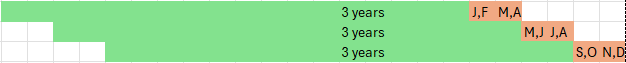

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [4]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

Test train / val split function:

In [5]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

folds = _build_validation_folds(
    data=DK1_train,
    train_window=3 * 8760,        # 8760 hours = 1 year
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,         # 168 hours = 1 week
    stride=13 * 168,               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=8760 - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Fold {folds[1]['fold']} train start: {folds[1]['train_start']} - train end: {folds[1]['train_end']}")
print(f"Number of folds: {num_folds}")
print(f"Validation window start: {val_start} - validation window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} val start: {folds[fold]['val_start']} - val end: {folds[fold]['val_end']}")
# print(f"Fold {folds[1]['fold']} val start: {folds[1]['val_start']} - val end: {folds[1]['val_end']}")

Fold 1 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Fold 2 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Number of folds: 4
Validation window start: 2024-01-01 00:00:00 - validation window end: 2024-12-30 23:00:00
Prediction period: 28 days 00:00:00
Fold 1 val start: 2024-01-01 00:00:00 - val end: 2024-01-28 23:00:00
Fold 2 val start: 2024-04-01 00:00:00 - val end: 2024-04-28 23:00:00
Fold 3 val start: 2024-07-01 00:00:00 - val end: 2024-07-28 23:00:00
Fold 4 val start: 2024-09-30 00:00:00 - val end: 2024-10-27 23:00:00


Hyperparameter search

In [6]:
param_grid = {
    "order": [
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1),
        (2, 1, 0),
        (2, 1, 1),
        (3, 1, 1),
    ]
}


def run_arimax_search(
    *,
    price_zone,
    train_data,
    test_data,
    param_grid,
    output_subfolder,
    base_filename,
    train_window,
    val_window,
    val_start,
    predict_period,
    stride,
    rf_models,
    forecast_horizon=168,
    exog_feature_columns=None,
):
    dataset = pd.concat([train_data, test_data], ignore_index=True)
    dataset = dataset.sort_values("Time").reset_index(drop=True)
    dataset.attrs["dk_zone"] = price_zone
    target_col = dataset.columns[0]

    if exog_feature_columns is None:
        feature_columns = _get_feature_columns(dataset, target_col)
    else:
        feature_columns = exog_feature_columns
    
    print(f"Exogenous features: {len(feature_columns)}\n{feature_columns}")

    folds = _build_validation_folds(
        data=dataset,
        train_window=train_window,
        val_window=val_window,
        val_start=val_start,
        predict_period=predict_period,
        stride=stride,
    )

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    num_combinations = len(all_combinations)

    print(f"\nTotal number of combinations to test: {num_combinations}")

    results = []
    for comb_number, combination in enumerate(all_combinations, start=1):
        params = dict(zip(param_names, combination))
        order = params["order"]

        print(f"\nCombination {comb_number}/{num_combinations}: {params}")

        weekly_results = []
        daily_results = []

        try:
            fold_no = 0
            for fold in folds:
                fold_no += 1
                print(f"Fold {fold_no}/{len(folds)}...", flush=True)
                train_mask = (
                    (dataset["Time"] >= fold["train_start"])
                    & (dataset["Time"] <= fold["train_end"])
                )
                fold_train = dataset.loc[train_mask].copy()

                train_series = _prepare_target_series(fold_train, target_col)
                train_exog = _clean_exog(
                    fold_train[["Time"] + feature_columns].set_index("Time")[feature_columns]
                )

                fitted_model = _fit_arimax(train_series, train_exog, order=order)

                fold_actual_mask = (
                    (dataset["Time"] >= fold["val_start"])
                    & (dataset["Time"] <= fold["val_end"])
                )
                fold_actual = _prepare_target_series(dataset.loc[fold_actual_mask], target_col)

                fold_exog = _forecast_exog_for_period(
                    dataset=dataset,
                    period_start=fold["val_start"],
                    period_end=fold["val_end"],
                    feature_columns=feature_columns,
                    dk_zone=price_zone,
                    rf_models=rf_models,
                    forecast_horizon=forecast_horizon,
                )

                fold_forecast = pd.Series(
                    fitted_model.get_forecast(
                        steps=len(fold_exog),
                        exog=_clean_exog(fold_exog),
                    ).predicted_mean,
                    index=fold_exog.index,
                )

                if len(fold_actual) != len(fold_forecast):
                    raise ValueError(
                        f"Forecast length mismatch in fold {fold['fold']}: "
                        f"actual={len(fold_actual)}, predicted={len(fold_forecast)}"
                    )

                for week_no, start in enumerate(range(0, len(fold_actual), 168), start=1):
                    week_actual = fold_actual.iloc[start:start + 168]
                    week_pred = fold_forecast.iloc[start:start + 168]

                    weekly_row, daily_rows = _build_weekly_and_daily_metrics(
                        actual=week_actual,
                        predicted=week_pred,
                        fold_no=fold["fold"],
                        week_no=week_no,
                    )
                    weekly_results.append(weekly_row)
                    daily_results.append(daily_rows)
                    
        except Exception as exc:
            print(f"Combination {comb_number} failed: {exc}")
            continue

        weekly_results_df = pd.DataFrame(weekly_results)
        daily_results_df = pd.concat(daily_results, ignore_index=True)
        daily_results_df = daily_results_df.sort_values(["fold", "week", "Date"]).reset_index(drop=True)
        daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

        overall_daily_rmse_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
        )
        overall_daily_mae_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
        )
        overall_daily_smape_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
        )

        avg_smape_by_day = {
            f"avg_smape_day_{day}": daily_results_df.loc[
                daily_results_df["day_in_week"] == day,
                "daily_smape",
            ].mean()
            for day in range(1, 8)
        }

        row = {
            **params,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values("avg_smape")

    folder = os.path.join(project_root, "Shallow learners", output_subfolder)
    os.makedirs(folder, exist_ok=True)
    filename = os.path.join(folder, f"{base_filename}.csv")

    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1

    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    return results_df, filename, feature_columns

exo_features = ["WindSpeed", 
                "Radiation", 
                "GrossCon", 
                "OffshoreWindCapacity", 
                "OnshoreWindCapacity", 
                "SolarPowerCapacity", 
                "GrossCon_lag1", 
                "GrossCon_lag24"]

In [7]:
results_df, filename, used_feature_columns = run_arimax_search(
    price_zone="DK1",
    train_data=DK1_train,
    test_data=DK1_test,
    param_grid=param_grid,
    output_subfolder="ARIMA-ARIMAX",
    base_filename="DK1_hyperparameter_search_ARIMAX_results",
    train_window=3 * 8760,
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,
    stride=13 * 168,
    rf_models=rf_models,
    forecast_horizon=168,
    exog_feature_columns=exo_features,
)

print(results_df.head())

Exogenous features: 8
['WindSpeed', 'Radiation', 'GrossCon', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'GrossCon_lag1', 'GrossCon_lag24']

Total number of combinations to test: 6

Combination 1/6: {'order': (0, 1, 1)}
Fold 1/4...
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - F

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [32]:
param_grid = {
    "order": [
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1),
        (2, 1, 0),
        (2, 1, 1),
        (3, 1, 1),
    ]
}

print(f"Total number of combinations to test: {len(param_grid['order'])}")

Total number of combinations to test: 6


In [33]:
results_df, filename, used_feature_columns = run_arimax_search(
    price_zone="DK2",
    train_data=DK2_train,
    test_data=DK2_test,
    param_grid=param_grid,
    output_subfolder="ARIMA-ARIMAX",
    base_filename="DK2_hyperparameter_search_ARIMAX_results",
    train_window=3 * 8760,
    val_window=8760,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,
    stride=13 * 168,
    rf_models=rf_models,
    forecast_horizon=168,
    exog_feature_columns=exo_features,
)

print(results_df.head())

Exogenous features: 8
['WindSpeed', 'Radiation', 'GrossCon', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'GrossCon_lag1', 'GrossCon_lag24']

Total number of combinations to test: 6

Combination 1/6: {'order': (0, 1, 1)}
Fold 1/4...
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - F

## Train and test final model

Make train and test periods

In [8]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        # 8760 hours = 1 year
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2016-01-02 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


Train and test the final model

In [9]:
import os
import pandas as pd
from time import time

# Set price zone and final ARIMAX order
price_zone = "DK1"
final_order = (0, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test


start_time = time()
dataset = pd.concat([train_data, test_data], ignore_index=True)
dataset = dataset.sort_values("Time").reset_index(drop=True)
dataset.attrs["dk_zone"] = price_zone
target_col = dataset.columns[0]
feature_columns = _get_feature_columns(dataset, target_col)

train_series = _prepare_target_series(train_data, target_col)
train_exog = _clean_exog(
    train_data[["Time"] + feature_columns].set_index("Time")[feature_columns]
)

test_series = _prepare_target_series(test_data, target_col)

time_check = time() - start_time
print("Forecasting exogenous features...({:.2f} sec)".format(time_check))
test_exog_forecast = _forecast_exog_for_period(
    dataset=dataset,
    period_start=test_data["Time"].min(),
    period_end=test_data["Time"].max(),
    feature_columns=feature_columns,
    dk_zone=price_zone,
    rf_models=rf_models,
    forecast_horizon=168,
)

print("Training model... ({:.2f} sec)".format(time() - start_time))

fitted_model = _fit_arimax(train_series, train_exog, final_order)
forecast = pd.Series(
    fitted_model.get_forecast(
        steps=len(test_exog_forecast),
        exog=_clean_exog(test_exog_forecast),
    ).predicted_mean,
    index=test_exog_forecast.index,
)

print("Model trained. Evaluating... ({:.2f} sec)".format(time() - start_time))

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.reindex(test_series.index).values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

    if week_no % 10 == 0:
        print(f"  week {week_no}: {weekly_rows[-1]['weekly_smape']:.2f}% SMAPE")

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners", "ARIMA-ARIMAX")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMAX_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")
print(f"\nResults saved to: {filename}")

# Keep objects for SHAP/explainability cell
arimax_final_bundle = {
    "model": fitted_model,
    "price_zone": price_zone,
    "target_col": target_col,
    "feature_columns": feature_columns,
    "train_exog": train_exog,
    "test_exog_forecast": _clean_exog(test_exog_forecast),
    "train_fitted": pd.Series(fitted_model.fittedvalues, index=train_series.index),
    "test_forecast": forecast,
}

Forecasting exogenous features...(0.11 sec)
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Forecasting 2/4: OnshoreWindPower 
  - Forecasting 3/4: SolarPower 
  - Forecasting 4/4: TotalProduction 
  Forecasting non-RF features...
  Forecasting RF features...
  - Forecasting 1/4: OffshoreWindPower 
  - Fo

SHAP analysis (surrogate explainer for ARIMAX outputs)

Available RAM before SHAP: 13.50 GB
Rows used for SHAP surrogate: 87660
Number of features: 34

SHAP analysis complete.


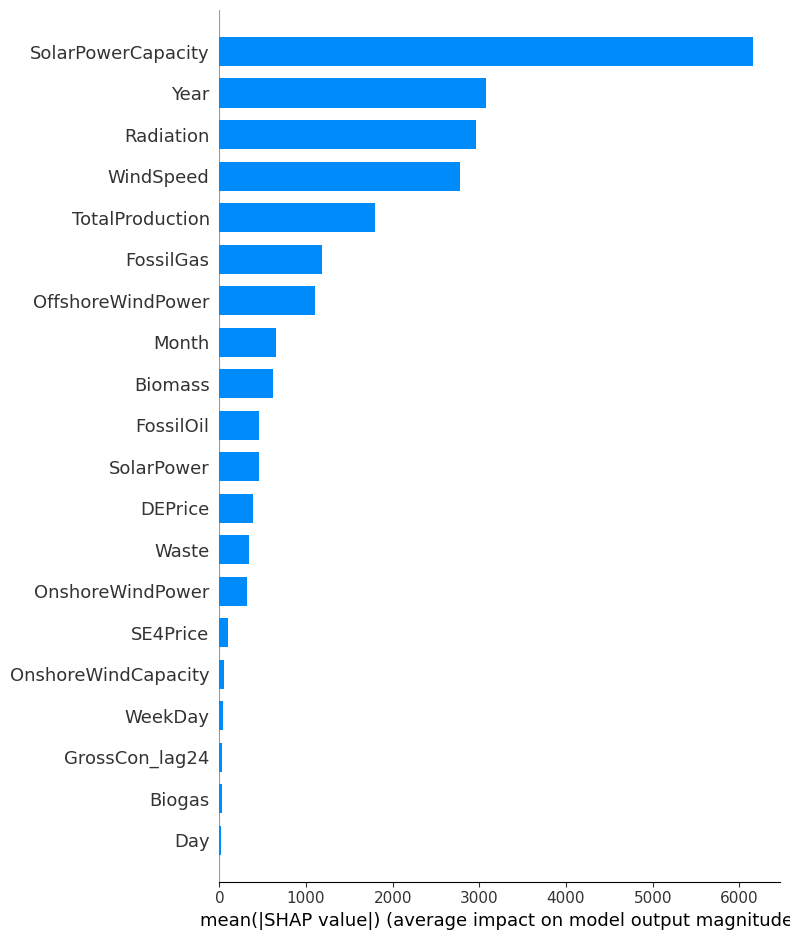

<Figure size 640x480 with 0 Axes>

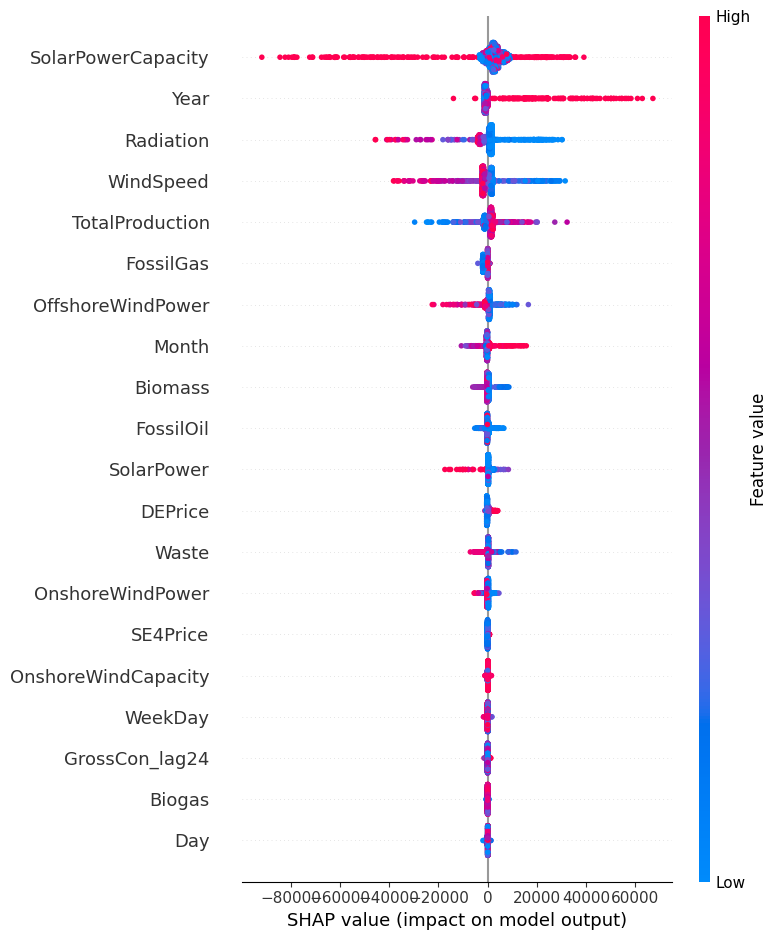

<Figure size 640x480 with 0 Axes>

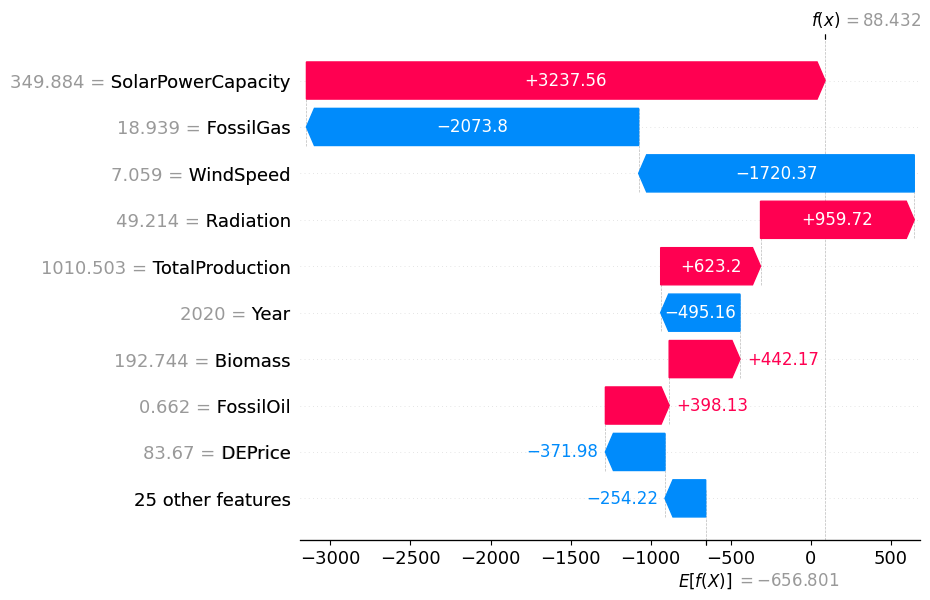

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 13.70 GB
Available RAM after SHAP cleanup: 13.71 GB


In [35]:
import gc
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from sklearn.ensemble import RandomForestRegressor

# ==========================
# SHAP configuration
# ==========================
quick_mode = False
eval_size = 2000
bg_size = 1000
include_beeswarm = True
include_waterfall = True

if "arimax_final_bundle" not in globals():
    raise ValueError("Run the 'Train and test the final model' cell before SHAP analysis.")

feature_columns = arimax_final_bundle["feature_columns"]
X_train = arimax_final_bundle["train_exog"][feature_columns].copy()
X_test = arimax_final_bundle["test_exog_forecast"][feature_columns].copy()

y_train_hat = arimax_final_bundle["train_fitted"].reindex(X_train.index)
y_test_hat = arimax_final_bundle["test_forecast"].reindex(X_test.index)

X_all = pd.concat([X_train, X_test], axis=0)
y_all_hat = pd.concat([y_train_hat, y_test_hat], axis=0)

mask = y_all_hat.notna()
X_all = X_all.loc[mask].astype(np.float32, copy=False)
y_all_hat = y_all_hat.loc[mask].astype(float)

if len(X_all) == 0:
    raise ValueError("No rows available for SHAP analysis.")

mem = psutil.virtual_memory()
print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
print(f"Rows used for SHAP surrogate: {len(X_all)}")
print(f"Number of features: {len(feature_columns)}")

if quick_mode:
    bg_size = min(20, len(X_all))
    eval_size = min(80, len(X_all))
else:
    bg_size = min(bg_size, len(X_all))
    eval_size = min(eval_size, len(X_all))

X_bg = shap.sample(X_all, bg_size, random_state=42)
X_eval = shap.sample(X_all, eval_size, random_state=42)

# Surrogate model to explain ARIMAX outputs with TreeSHAP.
surrogate_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
surrogate_model.fit(X_all, y_all_hat)

explainer = shap.TreeExplainer(surrogate_model)
shap_values = explainer.shap_values(X_eval)

print("\nSHAP analysis complete.")

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_eval, plot_type="bar", show=True)
plt.tight_layout()
plt.show()
plt.close()

if include_beeswarm:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_eval, show=True)
    plt.tight_layout()
    plt.show()
    plt.close()

if include_waterfall:
    i = 0
    base_value = explainer.expected_value
    if isinstance(base_value, (list, tuple, np.ndarray)):
        base_value = np.array(base_value).reshape(-1)[0]

    plt.figure(figsize=(10, 4))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i],
            base_values=base_value,
            data=X_eval.iloc[i].values,
            feature_names=X_eval.columns.tolist(),
        )
    )
    plt.tight_layout()
    plt.show()
    plt.close()

mem_while_running = psutil.virtual_memory()
print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

del X_bg, X_eval, shap_values
gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")